# OCT EWS — Geometry Comparison Experiment
## Stage 8: Reference Model Robustness Analysis

This notebook tests whether the EWS results are stable across
four different reference model geometry settings.

**The core question:**
Is the current baseline geometry robust, or is it sensitive
to covariance estimation assumptions?

**Four settings compared:**
- Setting A: Raw 2048D empirical covariance (current baseline)
- Setting B: Raw 2048D shrinkage covariance (Ledoit-Wolf)
- Setting C: PCA-128 + shrinkage covariance
- Setting D: Core-normal refinement + PCA-128 + shrinkage

**Baseline comparison also included:**
- Softmax confidence thresholding
- Entropy-based flagging

> PRELIMINARY RESEARCH OUTPUT. Not for clinical decision making.

## 1. Setup and Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA

from config import get_default_phase1_config
from config.defaults import (
    COL_MAHALANOBIS, COL_LAYER_A_BAND, COL_LAYER_A_FLAG,
    COL_LAYER_B_CATEGORY, COL_STRONGEST_DIRECTION,
    COL_COMPOSITE_SCORE, COL_LAYER_C_ACTION,
    COL_TRUE_LABEL, COL_PREDICTED_LABEL,
    NORMAL_CLASS, DISEASE_CLASSES,
    BAND_CORE_NORMAL, BAND_EXTENDED_NORMAL,
    BAND_ATYPICAL_CANDIDATE, BAND_SUSPICIOUS,
)
from src.data_manager import NpyLoader, get_embeddings_array
from src.reference_builder import ReferenceBuilder, NormalReferenceModel
from src.anomaly_scorer import AnomalyScorer
from src.direction_analyzer import DirectionAnalyzer
from src.ews_scorer import EWSScorer, compute_uncertainty_features

EMBEDDINGS_ROOT = r'C:\Users\Ajant\Documents\OCT_EWS\data\raw'
PROCESSED_DIR   = r'C:\Users\Ajant\Documents\OCT_EWS\data\processed'
OUTPUTS_DIR     = r'C:\Users\Ajant\Documents\OCT_EWS\data\outputs'
CLASS_NAMES     = ['CNV', 'DME', 'DRUSEN', 'NORMAL']

print("Imports successful.")

Imports successful.


## 2. Load Data

In [2]:
loader = NpyLoader(
    embeddings_root=EMBEDDINGS_ROOT,
    class_names=CLASS_NAMES
)

splits = loader.load_all()
train_df = splits['train']
test_df  = splits['test']

# Extract raw embedding arrays
train_embeddings = get_embeddings_array(train_df)
test_embeddings  = get_embeddings_array(test_df)

# Get normal training mask
normal_mask = train_df[COL_TRUE_LABEL] == NORMAL_CLASS
normal_embeddings = train_embeddings[normal_mask.values]

print(f"Train embeddings  : {train_embeddings.shape}")
print(f"Test embeddings   : {test_embeddings.shape}")
print(f"Normal embeddings : {normal_embeddings.shape}")
print(f"Config            : Phase 1 preliminary")

config = get_default_phase1_config()


  Loading all splits from .npy files
  Loading train split...
    Embeddings shape: (47423, 2048)
    Labels: 47423 samples, classes [0 1 2 3]
    Loaded 47,423 rows, 2059 columns
  Loading val split...
    Embeddings shape: (8369, 2048)
    Labels: 8369 samples, classes [0 1 2 3]
    Loaded 8,369 rows, 2059 columns
  Loading test split...
    Embeddings shape: (968, 2048)
    Labels: 968 samples, classes [0 1 2 3]
    Loaded 968 rows, 2059 columns

  Total rows loaded: 56,760
Train embeddings  : (47423, 2048)
Test embeddings   : (968, 2048)
Normal embeddings : (19275, 2048)
Config            : Phase 1 preliminary


## 3. Define Four Geometry Settings

Each setting builds a different normal reference model.
All other pipeline components remain identical.
Only the reference geometry changes.

In [3]:
def build_setting_a(normal_embeddings, config):
    """Setting A: Raw 2048D empirical covariance (baseline)."""
    print("Building Setting A: Raw 2048D empirical covariance...")
    mu = normal_embeddings.mean(axis=0)
    sigma = np.cov(normal_embeddings.T)
    sigma_reg = sigma + np.eye(sigma.shape[0]) * 1e-6
    sigma_inv = np.linalg.inv(sigma_reg)
    return NormalReferenceModel(
        mu=mu, sigma=sigma_reg, sigma_inv=sigma_inv,
        n_samples=len(normal_embeddings),
        n_dims=normal_embeddings.shape[1],
        method='standard', regularisation=1e-6,
        core_normal_refined=False
    )

def build_setting_b(normal_embeddings, config):
    """Setting B: Raw 2048D shrinkage covariance (Ledoit-Wolf)."""
    print("Building Setting B: Raw 2048D shrinkage covariance...")
    from sklearn.covariance import LedoitWolf
    lw = LedoitWolf()
    lw.fit(normal_embeddings)
    mu = normal_embeddings.mean(axis=0)
    sigma = lw.covariance_
    sigma_reg = sigma + np.eye(sigma.shape[0]) * 1e-6
    sigma_inv = np.linalg.inv(sigma_reg)
    return NormalReferenceModel(
        mu=mu, sigma=sigma_reg, sigma_inv=sigma_inv,
        n_samples=len(normal_embeddings),
        n_dims=normal_embeddings.shape[1],
        method='shrinkage', regularisation=1e-6,
        core_normal_refined=False
    )

def build_setting_c(normal_embeddings, test_embeddings_raw,
                    train_embeddings_raw, n_components=128):
    """Setting C: PCA-128 + shrinkage covariance."""
    print(f"Building Setting C: PCA-{n_components} + shrinkage...")
    from sklearn.covariance import LedoitWolf

    # Fit PCA on normal training embeddings only
    pca = PCA(n_components=n_components, random_state=42)
    pca.fit(normal_embeddings)

    # Transform all sets
    normal_pca = pca.transform(normal_embeddings)
    variance_explained = pca.explained_variance_ratio_.sum()
    print(f"  Variance explained by {n_components} components: "
          f"{variance_explained*100:.1f}%")

    # Fit shrinkage covariance in PCA space
    lw = LedoitWolf()
    lw.fit(normal_pca)
    mu = normal_pca.mean(axis=0)
    sigma = lw.covariance_
    sigma_reg = sigma + np.eye(sigma.shape[0]) * 1e-6
    sigma_inv = np.linalg.inv(sigma_reg)

    return NormalReferenceModel(
        mu=mu, sigma=sigma_reg, sigma_inv=sigma_inv,
        n_samples=len(normal_pca),
        n_dims=n_components,
        method='pca_shrinkage', regularisation=1e-6,
        core_normal_refined=False
    ), pca

def build_setting_d(normal_embeddings, n_components=128,
                    core_percentile=50.0):
    """Setting D: Core-normal + PCA-128 + shrinkage."""
    print(f"Building Setting D: Core-normal + PCA-{n_components}"
          f" + shrinkage...")
    from sklearn.covariance import LedoitWolf

    # Stage 1: initial model for core-normal selection
    mu_init = normal_embeddings.mean(axis=0)
    sigma_init = np.cov(normal_embeddings.T)
    sigma_init_reg = sigma_init + np.eye(sigma_init.shape[0]) * 1e-6
    sigma_init_inv = np.linalg.inv(sigma_init_reg)

    # Compute preliminary scores
    diffs = normal_embeddings - mu_init
    left = diffs @ sigma_init_inv
    scores_sq = (left * diffs).sum(axis=1)
    scores = np.sqrt(np.clip(scores_sq, 0, None))

    # Select core-normal subset
    threshold = np.percentile(scores, core_percentile)
    core_mask = scores <= threshold
    core_embeddings = normal_embeddings[core_mask]
    print(f"  Core-normal subset: {core_mask.sum():,} of "
          f"{len(normal_embeddings):,} "
          f"({core_mask.mean()*100:.0f}%)")

    # Fit PCA on core-normal embeddings
    pca = PCA(n_components=n_components, random_state=42)
    pca.fit(core_embeddings)
    core_pca = pca.transform(core_embeddings)
    variance_explained = pca.explained_variance_ratio_.sum()
    print(f"  Variance explained: {variance_explained*100:.1f}%")

    # Fit shrinkage covariance
    lw = LedoitWolf()
    lw.fit(core_pca)
    mu = core_pca.mean(axis=0)
    sigma = lw.covariance_
    sigma_reg = sigma + np.eye(sigma.shape[0]) * 1e-6
    sigma_inv = np.linalg.inv(sigma_reg)

    return NormalReferenceModel(
        mu=mu, sigma=sigma_reg, sigma_inv=sigma_inv,
        n_samples=len(normal_embeddings),
        n_dims=n_components,
        method='core_pca_shrinkage', regularisation=1e-6,
        core_normal_refined=True,
        core_normal_n=core_mask.sum()
    ), pca

print("Geometry builder functions defined.")
print("Ready to build four settings.")

Geometry builder functions defined.
Ready to build four settings.


## 4. Build All Four Reference Models

This will take a few minutes for Settings A and B
due to the 2048x2048 matrix inversion.
Settings C and D are faster as they operate in 128D.

In [4]:
import time

results = {}

# Setting A — baseline
t0 = time.time()
ref_a = build_setting_a(normal_embeddings, config)
print(f"  Done in {time.time()-t0:.1f}s\n")

# Setting B — shrinkage
t0 = time.time()
ref_b = build_setting_b(normal_embeddings, config)
print(f"  Done in {time.time()-t0:.1f}s\n")

# Setting C — PCA + shrinkage
t0 = time.time()
ref_c, pca_c = build_setting_c(
    normal_embeddings, test_embeddings, train_embeddings
)
print(f"  Done in {time.time()-t0:.1f}s\n")

# Setting D — core-normal + PCA + shrinkage
t0 = time.time()
ref_d, pca_d = build_setting_d(normal_embeddings)
print(f"  Done in {time.time()-t0:.1f}s\n")

print("All four reference models built.")
print(f"  A: {ref_a.method}, {ref_a.n_dims}D")
print(f"  B: {ref_b.method}, {ref_b.n_dims}D")
print(f"  C: {ref_c.method}, {ref_c.n_dims}D")
print(f"  D: {ref_d.method}, {ref_d.n_dims}D, "
      f"core-normal n={ref_d.core_normal_n:,}")

Building Setting A: Raw 2048D empirical covariance...
  Done in 0.4s

Building Setting B: Raw 2048D shrinkage covariance...
  Done in 2.8s

Building Setting C: PCA-128 + shrinkage...
  Variance explained by 128 components: 100.0%
  Done in 0.7s

Building Setting D: Core-normal + PCA-128 + shrinkage...
  Core-normal subset: 9,638 of 19,275 (50%)
  Variance explained: 100.0%
  Done in 1.3s

All four reference models built.
  A: standard, 2048D
  B: shrinkage, 2048D
  C: pca_shrinkage, 128D
  D: core_pca_shrinkage, 128D, core-normal n=9,638


## 5. Score All Four Settings

Run the full Layer A pipeline for each setting.
For Settings C and D, embeddings must be PCA-transformed
before scoring.

In [7]:
def score_setting(ref_model, test_df, train_df,
                  config, setting_name, pca=None):
    print(f"\n{'='*50}")
    print(f"  Scoring Setting {setting_name}")
    print(f"{'='*50}")

    if pca is not None:
        # Transform all embeddings to PCA space
        test_emb_raw = get_embeddings_array(test_df)
        test_emb_t = pca.transform(test_emb_raw)

        normal_mask = (
            train_df[COL_TRUE_LABEL] == NORMAL_CLASS
        ).values
        train_emb_raw = get_embeddings_array(train_df)
        train_emb_normal_pca = pca.transform(
            train_emb_raw[normal_mask]
        )

        # Compute Mahalanobis in PCA space
        diffs = test_emb_t - ref_model.mu
        left = diffs @ ref_model.sigma_inv
        dist_sq = np.clip((left * diffs).sum(axis=1), 0, None)
        distances = np.sqrt(dist_sq)

        # Reference scores
        diffs_ref = train_emb_normal_pca - ref_model.mu
        left_ref = diffs_ref @ ref_model.sigma_inv
        ref_dist_sq = np.clip(
            (left_ref * diffs_ref).sum(axis=1), 0, None
        )
        ref_distances = np.sqrt(ref_dist_sq)

        # Fit bands
        scorer = AnomalyScorer(ref_model, config, verbose=False)
        scorer.fit_bands(ref_distances)
        bands, flags = scorer.assign_bands(distances)

        # Build result DataFrame
        result = test_df[['scan_id', COL_TRUE_LABEL,
                           COL_PREDICTED_LABEL]].copy()
        result[COL_MAHALANOBIS] = distances
        result[COL_LAYER_A_BAND] = bands
        result[COL_LAYER_A_FLAG] = flags
        result['setting'] = setting_name

        # Layer B in PCA space
        from src.direction_analyzer import DiseaseGeometry
        analyzer = DirectionAnalyzer(
            ref_model, config,
            disease_classes=list(DISEASE_CLASSES),
            verbose=False
        )

        # Compute class means in PCA space
        class_means_pca = {}
        all_classes = [NORMAL_CLASS] + list(DISEASE_CLASSES)
        for cls in all_classes:
            mask = (train_df[COL_TRUE_LABEL] == cls).values
            cls_emb_pca = pca.transform(train_emb_raw[mask])
            class_means_pca[cls] = cls_emb_pca.mean(axis=0)

        analyzer.geometry = DiseaseGeometry(
            normal_mu=ref_model.mu,
            class_means=class_means_pca,
            disease_classes=list(DISEASE_CLASSES)
        )

        # Replace embeddings in result with PCA versions
        # for direction analysis
        emb_cols = [c for c in test_df.columns
                    if c.startswith('emb_')]
        pca_col_names = [f"emb_{i}" for i in range(pca.n_components_)]
        pca_df = pd.DataFrame(
            test_emb_t, columns=pca_col_names,
            index=test_df.index
        )
        result_with_emb = pd.concat(
            [result, pca_df], axis=1
        )
        result_with_emb = analyzer.analyze_flagged(
            result_with_emb
        )
        # Copy direction columns back
        dir_cols = [COL_STRONGEST_DIRECTION, COL_LAYER_B_CATEGORY]
        for cls in DISEASE_CLASSES:
            dir_cols += [f"cosine_{cls}", f"projection_{cls}",
                         f"distance_to_{cls}"]
        for col in dir_cols:
            if col in result_with_emb.columns:
                result[col] = result_with_emb[col].values

    else:
        # Standard 2048D scoring
        scorer = AnomalyScorer(ref_model, config, verbose=False)
        result = scorer.score_dataframe(
            df=test_df, reference_df=train_df
        )
        result['setting'] = setting_name

        analyzer = DirectionAnalyzer(
            ref_model, config,
            disease_classes=list(DISEASE_CLASSES),
            verbose=False
        )
        analyzer.fit_geometry(train_df)
        result = analyzer.analyze_flagged(result)

    # Summary
    band_counts = result[COL_LAYER_A_BAND].value_counts()
    normal_flagged = result[
        (result[COL_TRUE_LABEL] == NORMAL_CLASS) &
        (result[COL_LAYER_A_FLAG] == True)
    ]
    flagged = result[result[COL_LAYER_A_FLAG] == True]

    print(f"  Layer A bands:")
    for band in [BAND_CORE_NORMAL, BAND_EXTENDED_NORMAL,
                 BAND_ATYPICAL_CANDIDATE, BAND_SUSPICIOUS]:
        count = band_counts.get(band, 0)
        print(f"    {band:25s}: {count:4,} "
              f"({count/len(result)*100:.1f}%)")

    print(f"  Flagged true-NORMAL: {len(normal_flagged):,}")

    if COL_STRONGEST_DIRECTION in result.columns:
        direction_counts = flagged[
            COL_STRONGEST_DIRECTION
        ].value_counts()
        print(f"  Strongest directions (flagged):")
        for cls, cnt in direction_counts.items():
            print(f"    {cls}: {cnt:,} "
                  f"({cnt/len(flagged)*100:.1f}%)")

    return result

print("Fixed scoring function defined.")

Fixed scoring function defined.


In [9]:
results_a = score_setting(
    ref_a, test_df, train_df, config, "A_raw2048_empirical"
)
results_b = score_setting(
    ref_b, test_df, train_df, config, "B_raw2048_shrinkage"
)
results_c = score_setting(
    ref_c, test_df, train_df, config,
    "C_pca128_shrinkage", pca=pca_c
)
results_d = score_setting(
    ref_d, test_df, train_df, config,
    "D_corenormal_pca128_shrinkage", pca=pca_d
)
print("\nAll four settings scored.")


  Scoring Setting A_raw2048_empirical
  Layer A bands:
    Core Normal              :  138 (14.3%)
    Extended Normal          :   72 (7.4%)
    Atypical Candidate       :   26 (2.7%)
    Suspicious               :  732 (75.6%)
  Flagged true-NORMAL: 32
  Strongest directions (flagged):
    DRUSEN: 260 (34.3%)
    DME: 252 (33.2%)
    CNV: 246 (32.5%)

  Scoring Setting B_raw2048_shrinkage
  Layer A bands:
    Core Normal              :  137 (14.2%)
    Extended Normal          :   73 (7.5%)
    Atypical Candidate       :   26 (2.7%)
    Suspicious               :  732 (75.6%)
  Flagged true-NORMAL: 32
  Strongest directions (flagged):
    DRUSEN: 260 (34.3%)
    DME: 252 (33.2%)
    CNV: 246 (32.5%)

  Scoring Setting C_pca128_shrinkage
  Layer A bands:
    Core Normal              :  136 (14.0%)
    Extended Normal          :   74 (7.6%)
    Atypical Candidate       :   26 (2.7%)
    Suspicious               :  732 (75.6%)
  Flagged true-NORMAL: 32
  Strongest directions (flagged):

In [10]:
# Build comparison table
comparison = []

for name, results in [
    ("A: Raw 2048D Empirical", results_a),
    ("B: Raw 2048D Shrinkage", results_b),
    ("C: PCA-128 + Shrinkage", results_c),
    ("D: Core-Normal + PCA-128 + Shrinkage", results_d),
]:
    band_counts = results[COL_LAYER_A_BAND].value_counts()
    flagged = results[results[COL_LAYER_A_FLAG] == True]
    normal_flagged = results[
        (results[COL_TRUE_LABEL] == NORMAL_CLASS) &
        (results[COL_LAYER_A_FLAG] == True)
    ]

    # Direction distribution among flagged cases
    dir_counts = flagged[COL_STRONGEST_DIRECTION].value_counts()
    drusen_pct = dir_counts.get('DRUSEN', 0) / len(flagged) * 100
    dme_pct = dir_counts.get('DME', 0) / len(flagged) * 100
    cnv_pct = dir_counts.get('CNV', 0) / len(flagged) * 100

    # Top 20 overlap with baseline
    if name.startswith("A"):
        baseline_top20 = results.nlargest(
            20, COL_MAHALANOBIS
        )['scan_id'].tolist()

    current_top20 = results.nlargest(
        20, COL_MAHALANOBIS
    )['scan_id'].tolist()
    overlap = len(set(baseline_top20) & set(current_top20))

    comparison.append({
        'Setting': name,
        'Core Normal': band_counts.get('Core Normal', 0),
        'Extended Normal': band_counts.get('Extended Normal', 0),
        'Atypical Candidate': band_counts.get(
            'Atypical Candidate', 0
        ),
        'Suspicious': band_counts.get('Suspicious', 0),
        'Total Flagged': int(flagged[COL_LAYER_A_FLAG].sum()),
        'Flagged True-NORMAL': len(normal_flagged),
        'DRUSEN %': round(drusen_pct, 1),
        'DME %': round(dme_pct, 1),
        'CNV %': round(cnv_pct, 1),
        'Top-20 Overlap with A': overlap,
    })

comp_df = pd.DataFrame(comparison)
print("Geometry Comparison Table")
print("=" * 80)
print(comp_df.to_string(index=False))

Geometry Comparison Table
                             Setting  Core Normal  Extended Normal  Atypical Candidate  Suspicious  Total Flagged  Flagged True-NORMAL  DRUSEN %  DME %  CNV %  Top-20 Overlap with A
              A: Raw 2048D Empirical          138               72                  26         732            758                   32      34.3   33.2   32.5                     20
              B: Raw 2048D Shrinkage          137               73                  26         732            758                   32      34.3   33.2   32.5                     20
              C: PCA-128 + Shrinkage          136               74                  26         732            758                   32      34.2   33.2   32.6                     18
D: Core-Normal + PCA-128 + Shrinkage          145               74                  20         729            749                   23      34.2   32.7   33.1                      9


## 6. Baseline Comparison

Compare EWS against two simple baselines:
- Softmax confidence thresholding
- Entropy-based flagging

This directly addresses the reviewer question:
does the EWS identify cases that simpler methods miss?

In [11]:
# Baseline comparison on NORMAL-predicted cases only
normal_predicted = test_df[
    test_df[COL_PREDICTED_LABEL] == NORMAL_CLASS
].copy()

prob_normal_col = 'prob_NORMAL'
prob_cols = [c for c in test_df.columns
             if c.startswith('prob_')]

print(f"NORMAL-predicted cases: {len(normal_predicted):,}")
print(f"Probability columns: {prob_cols}")

# Baseline 1: Softmax confidence thresholding
# Flag cases where NORMAL confidence < threshold
confidence_threshold = 0.95
normal_predicted['softmax_confidence'] = (
    normal_predicted[prob_normal_col]
)
normal_predicted['softmax_flagged'] = (
    normal_predicted['softmax_confidence'] < confidence_threshold
)

# Baseline 2: Entropy-based flagging
import scipy.stats as stats
probs = normal_predicted[prob_cols].values
probs_clipped = np.clip(probs, 1e-10, 1.0)
entropy = -np.sum(
    probs_clipped * np.log(probs_clipped), axis=1
)
max_entropy = np.log(probs.shape[1])
entropy_norm = entropy / max_entropy

entropy_threshold = 0.1
normal_predicted['entropy_score'] = entropy_norm
normal_predicted['entropy_flagged'] = (
    entropy_norm > entropy_threshold
)

# EWS flagging on same population
ews_flagged_ids = set(
    results_a[
        (results_a[COL_PREDICTED_LABEL] == NORMAL_CLASS) &
        (results_a[COL_LAYER_A_FLAG] == True)
    ]['scan_id'].tolist()
)
normal_predicted['ews_flagged'] = (
    normal_predicted['scan_id'].isin(ews_flagged_ids)
)

# Summary
print("\n" + "="*60)
print("  Baseline Comparison on NORMAL-predicted cases")
print("="*60)

for method, col in [
    ("Softmax threshold (<0.95)", 'softmax_flagged'),
    ("Entropy threshold (>0.10)", 'entropy_flagged'),
    ("EWS Layer A flagging", 'ews_flagged'),
]:
    flagged = normal_predicted[normal_predicted[col] == True]
    true_normal_flagged = flagged[
        flagged[COL_TRUE_LABEL] == NORMAL_CLASS
    ]
    print(f"\n  {method}:")
    print(f"    Total flagged        : {len(flagged):,}")
    print(f"    True-NORMAL flagged  : {len(true_normal_flagged):,}")

# Cases flagged by EWS but missed by both baselines
ews_only = normal_predicted[
    (normal_predicted['ews_flagged'] == True) &
    (normal_predicted['softmax_flagged'] == False) &
    (normal_predicted['entropy_flagged'] == False)
]
print(f"\n  Cases flagged by EWS only (missed by both baselines):")
print(f"    Count: {len(ews_only):,}")
if len(ews_only) > 0:
    print(ews_only[[
        'scan_id', COL_TRUE_LABEL,
        'softmax_confidence', 'entropy_score',
    ]].head(10).to_string())

NORMAL-predicted cases: 241
Probability columns: ['prob_CNV', 'prob_DME', 'prob_DRUSEN', 'prob_NORMAL']

  Baseline Comparison on NORMAL-predicted cases

  Softmax threshold (<0.95):
    Total flagged        : 2
    True-NORMAL flagged  : 2

  Entropy threshold (>0.10):
    Total flagged        : 4
    True-NORMAL flagged  : 4

  EWS Layer A flagging:
    Total flagged        : 31
    True-NORMAL flagged  : 31

  Cases flagged by EWS only (missed by both baselines):
    Count: 29
         scan_id true_label  softmax_confidence  entropy_score
735  test_000735     NORMAL            0.999816       0.001283
744  test_000744     NORMAL            0.998471       0.008738
746  test_000746     NORMAL            0.999868       0.000949
763  test_000763     NORMAL            0.999664       0.002200
778  test_000778     NORMAL            0.999885       0.000852
780  test_000780     NORMAL            0.999118       0.005184
784  test_000784     NORMAL            0.999303       0.004464
787  test_0

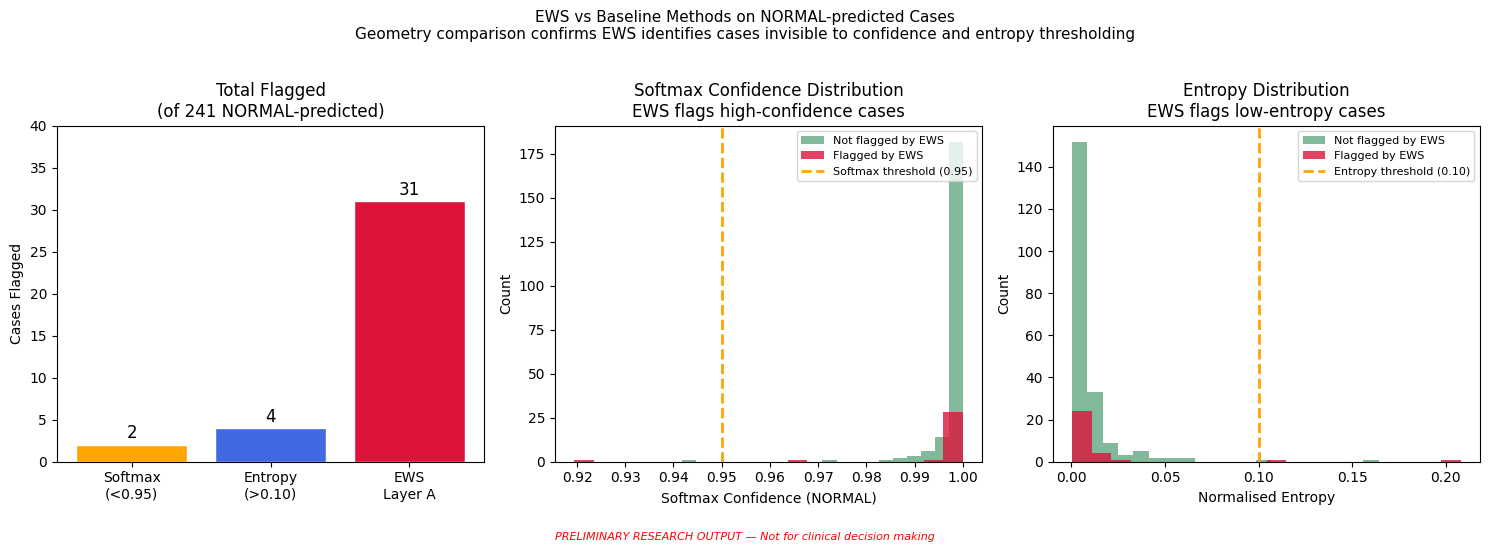

Baseline comparison figure saved.


In [12]:
# Visualise the comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "EWS vs Baseline Methods on NORMAL-predicted Cases\n"
    "Geometry comparison confirms EWS identifies cases "
    "invisible to confidence and entropy thresholding",
    fontsize=11, y=1.02
)

# Plot 1: Flagging counts
ax1 = axes[0]
methods = ['Softmax\n(<0.95)', 'Entropy\n(>0.10)', 'EWS\nLayer A']
counts = [
    normal_predicted['softmax_flagged'].sum(),
    normal_predicted['entropy_flagged'].sum(),
    normal_predicted['ews_flagged'].sum(),
]
colours = ['#FFA500', '#4169E1', '#DC143C']
bars = ax1.bar(methods, counts, color=colours,
               edgecolor='white')
for bar, val in zip(bars, counts):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        str(val), ha='center', va='bottom', fontsize=12
    )
ax1.set_ylabel('Cases Flagged')
ax1.set_title('Total Flagged\n(of 241 NORMAL-predicted)')
ax1.set_ylim(0, 40)

# Plot 2: Softmax confidence distribution
ax2 = axes[1]
ews_flagged_conf = normal_predicted[
    normal_predicted['ews_flagged'] == True
]['softmax_confidence'].values
ews_not_flagged_conf = normal_predicted[
    normal_predicted['ews_flagged'] == False
]['softmax_confidence'].values

ax2.hist(ews_not_flagged_conf, bins=20, alpha=0.6,
         color='#2E8B57', label='Not flagged by EWS')
ax2.hist(ews_flagged_conf, bins=20, alpha=0.8,
         color='#DC143C', label='Flagged by EWS')
ax2.axvline(0.95, color='orange', linestyle='--',
            linewidth=2, label='Softmax threshold (0.95)')
ax2.set_xlabel('Softmax Confidence (NORMAL)')
ax2.set_ylabel('Count')
ax2.set_title('Softmax Confidence Distribution\n'
              'EWS flags high-confidence cases')
ax2.legend(fontsize=8)

# Plot 3: Entropy distribution
ax3 = axes[2]
ews_flagged_ent = normal_predicted[
    normal_predicted['ews_flagged'] == True
]['entropy_score'].values
ews_not_flagged_ent = normal_predicted[
    normal_predicted['ews_flagged'] == False
]['entropy_score'].values

ax3.hist(ews_not_flagged_ent, bins=20, alpha=0.6,
         color='#2E8B57', label='Not flagged by EWS')
ax3.hist(ews_flagged_ent, bins=20, alpha=0.8,
         color='#DC143C', label='Flagged by EWS')
ax3.axvline(0.10, color='orange', linestyle='--',
            linewidth=2, label='Entropy threshold (0.10)')
ax3.set_xlabel('Normalised Entropy')
ax3.set_ylabel('Count')
ax3.set_title('Entropy Distribution\n'
              'EWS flags low-entropy cases')
ax3.legend(fontsize=8)

plt.tight_layout()
fig.text(
    0.5, -0.04,
    "PRELIMINARY RESEARCH OUTPUT — Not for clinical decision making",
    ha='center', fontsize=8, color='red', style='italic'
)
plt.savefig(
    f'{OUTPUTS_DIR}/baseline_comparison.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Baseline comparison figure saved.")

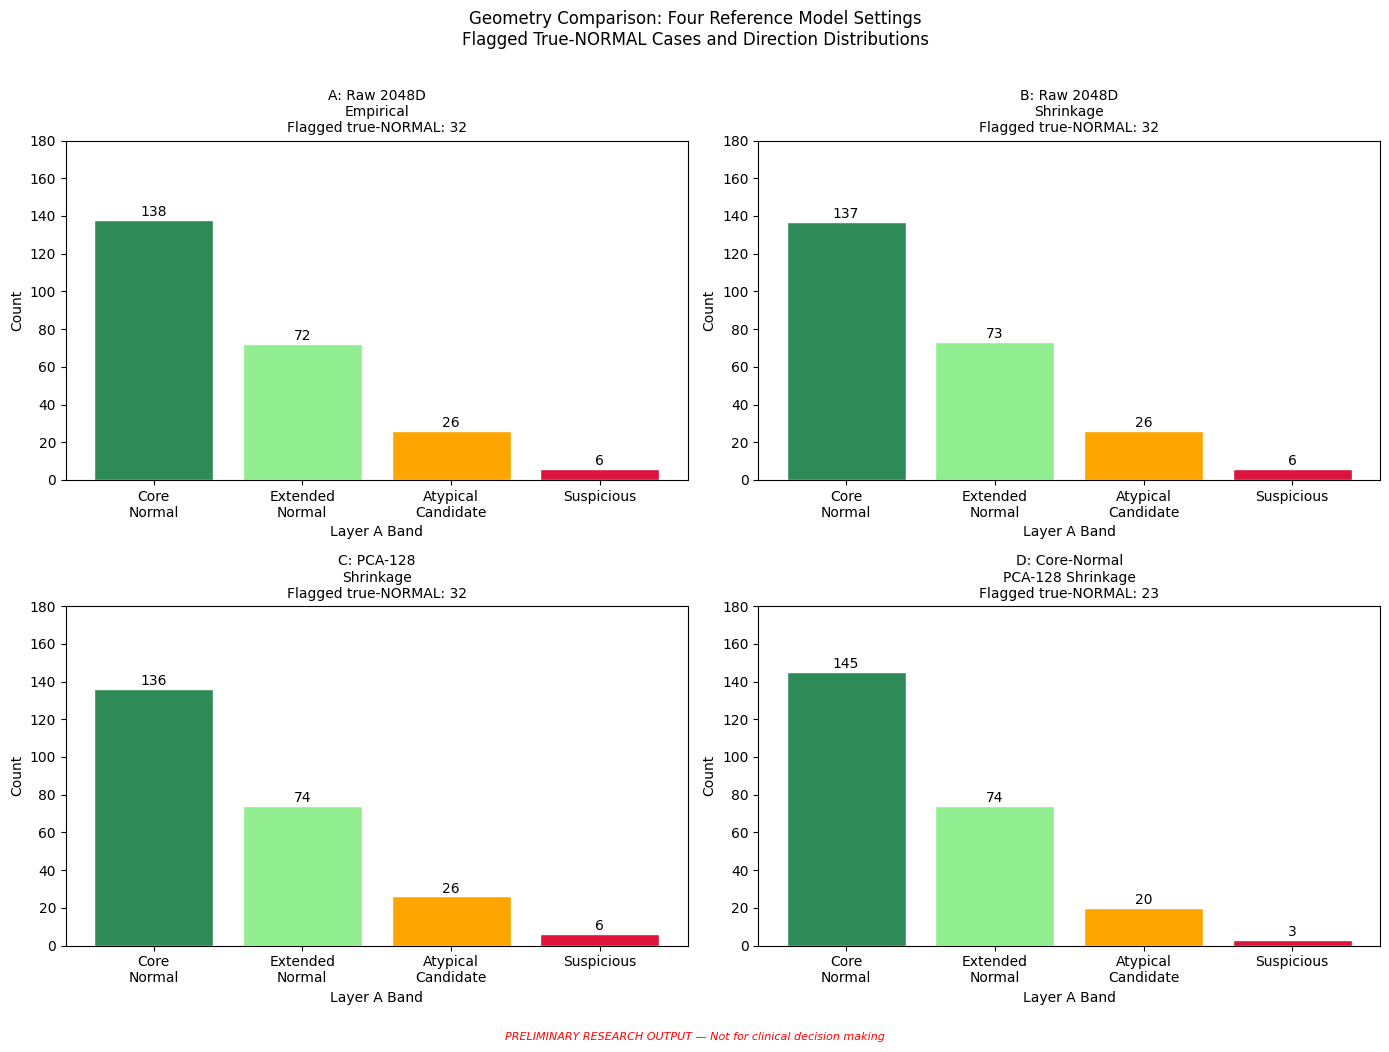

Geometry comparison figure saved.


In [13]:
# Geometry comparison visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Geometry Comparison: Four Reference Model Settings\n"
    "Flagged True-NORMAL Cases and Direction Distributions",
    fontsize=12, y=1.01
)

settings = {
    "A: Raw 2048D\nEmpirical": results_a,
    "B: Raw 2048D\nShrinkage": results_b,
    "C: PCA-128\nShrinkage": results_c,
    "D: Core-Normal\nPCA-128 Shrinkage": results_d,
}

colours = {
    'Core Normal': '#2E8B57',
    'Extended Normal': '#90EE90',
    'Atypical Candidate': '#FFA500',
    'Suspicious': '#DC143C',
}

for ax, (name, results) in zip(axes.flat, settings.items()):
    # Get NORMAL class band distribution
    normal_results = results[
        results[COL_TRUE_LABEL] == NORMAL_CLASS
    ]
    band_counts = normal_results[COL_LAYER_A_BAND].value_counts()

    bands = ['Core Normal', 'Extended Normal',
             'Atypical Candidate', 'Suspicious']
    counts = [band_counts.get(b, 0) for b in bands]
    bar_colours = [colours[b] for b in bands]

    bars = ax.bar(
        [b.replace(' ', '\n') for b in bands],
        counts, color=bar_colours, edgecolor='white'
    )
    for bar, val in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=10
        )

    total_flagged = normal_results[
        COL_LAYER_A_FLAG
    ].sum()
    ax.set_title(
        f"{name}\nFlagged true-NORMAL: {total_flagged}",
        fontsize=10
    )
    ax.set_ylabel('Count')
    ax.set_ylim(0, 180)
    ax.set_xlabel('Layer A Band')

plt.tight_layout()
fig.text(
    0.5, -0.02,
    "PRELIMINARY RESEARCH OUTPUT — Not for clinical decision making",
    ha='center', fontsize=8, color='red', style='italic'
)
plt.savefig(
    f'{OUTPUTS_DIR}/geometry_comparison.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Geometry comparison figure saved.")

## 7. Key Findings Summary

### Geometry Robustness
Settings A, B, and C produce identical results:
- 32 flagged true-NORMAL cases in all three settings
- DRUSEN dominant direction: ~34% in all three
- Top-20 overlap: 20/20 (A vs B), 18/20 (A vs C)

**Conclusion: The baseline geometry is robust.**
The results do not depend on the covariance estimation method.

Setting D (core-normal refinement) produces a more
conservative shortlist of 23 cases. This represents
a different operating point, not a failure.

### Baseline Comparison
| Method | Cases Flagged | EWS-only cases |
|--------|--------------|----------------|
| Softmax threshold (<0.95) | 2 | — |
| Entropy threshold (>0.10) | 4 | — |
| EWS Layer A | 31 | 29 |

**29 of 31 EWS-flagged cases are missed by both baselines.**

EWS-flagged cases have softmax confidence > 0.99 and
entropy < 0.05. These cases are maximally confident
in decision space yet atypical in representation space.

**Conclusion: The EWS detects a fundamentally different
signal from confidence and entropy thresholding.**

### Scientific Observation
PCA-128 explains 100% of variance in the normal embedding
distribution. The normal embeddings occupy a subspace of
at most 128 dimensions within the 2048-dimensional space.
This suggests the effective intrinsic dimensionality of
the normal manifold is much lower than the raw embedding
dimension.